In [7]:
import pandas as pd
import numpy as np
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt
import markov_clustering as mc
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram

In [3]:
community = pd.read_csv(r'D:\BNFO286\Kaggle\bnfo286coelution\repl1_repl2_combined.tsv', header = 0, sep="\t")
community.head()

,xxx,repl1_1,repl1_2,repl1_3,repl1_4,repl1_5,repl1_6,repl1_7,repl1_8,repl1_9,...,repl2_63,repl2_64,repl2_65,repl2_66,repl2_67,repl2_68,repl2_69,repl2_70,repl2_71,repl2_72
0,0002Y95AH,NaN,NaN,NaN,2.263669,22.128841,51.762737,52.550846,49.825542,48.441952,...,553.849060,274.200378,286.662445,112.624908,47.87561,59.853748,63.270977,27.508387,30.672783,32.651031
1,00BDGD39O,NaN,NaN,4.324259,19.600451,80.607506,172.490936,179.236649,158.082748,139.140900,...,4.175920,NaN,3.220537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00BXY8FC6,NaN,NaN,5.754857,11.839447,53.564465,89.967712,76.064796,87.056900,74.854607,...,4.823446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00GQL2IWT,NaN,NaN,NaN,2.807737,13.327758,24.826971,23.496061,25.944332,24.684835,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00W2KCFX9,NaN,NaN,3.518204,7.602578,29.471481,78.761925,75.764984,56.365299,48.396515,...,NaN,4.695970,3.909930,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
community_a = community.fillna(0)
community_a.head()

,xxx,repl1_1,repl1_2,repl1_3,repl1_4,repl1_5,repl1_6,repl1_7,repl1_8,repl1_9,...,repl2_63,repl2_64,repl2_65,repl2_66,repl2_67,repl2_68,repl2_69,repl2_70,repl2_71,repl2_72
0,0002Y95AH,0.0,0.0,0.000000,2.263669,22.128841,51.762737,52.550846,49.825542,48.441952,...,553.849060,274.200378,286.662445,112.624908,47.87561,59.853748,63.270977,27.508387,30.672783,32.651031
1,00BDGD39O,0.0,0.0,4.324259,19.600451,80.607506,172.490936,179.236649,158.082748,139.140900,...,4.175920,0.000000,3.220537,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
2,00BXY8FC6,0.0,0.0,5.754857,11.839447,53.564465,89.967712,76.064796,87.056900,74.854607,...,4.823446,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
3,00GQL2IWT,0.0,0.0,0.000000,2.807737,13.327758,24.826971,23.496061,25.944332,24.684835,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
4,00W2KCFX9,0.0,0.0,3.518204,7.602578,29.471481,78.761925,75.764984,56.365299,48.396515,...,0.000000,4.695970,3.909930,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
# Extract fraction columns (excluding protein ID)
fraction_data = community_a.iloc[:, 1:]

# Compute mean and standard deviation across fractions (ignoring NaNs)
fraction_mean = np.nanmean(fraction_data, axis=1, keepdims=True)
fraction_std = np.nanstd(fraction_data, axis=1, keepdims=True) + 1e-8  # Avoid division by zero

# Apply Z-score normalization
z_score_data = (fraction_data - fraction_mean) / fraction_std

# Convert back to DataFrame
z_score_df = pd.DataFrame(z_score_data, columns=fraction_data.columns)
z_score_df.insert(0, "xxx", community_a["xxx"])  # Re-add protein ID


In [9]:
# Compute Pearson correlation matrix on Z-scored data
corr_matrix = z_score_df.iloc[:, 1:].T.corr(method="pearson")


C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:8

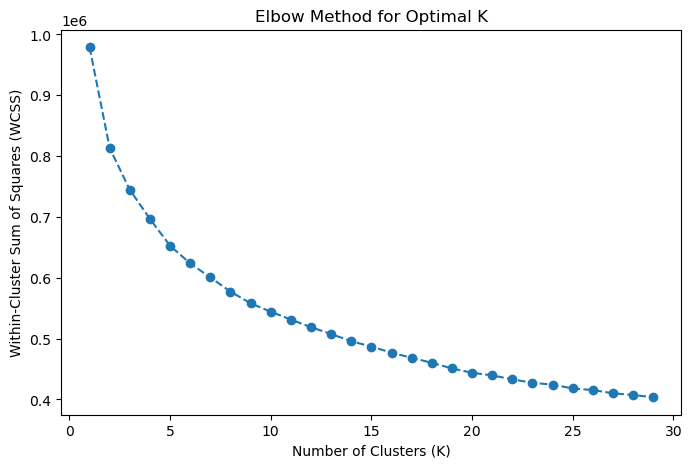

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Test different K values
wcss = []
K_range = range(1, 30)  # Try from 1 to 15 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(z_score_df.iloc[:, 1:])  # Use standardized data
    wcss.append(kmeans.inertia_)  # Inertia = sum of squared distances

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.show()

C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:8

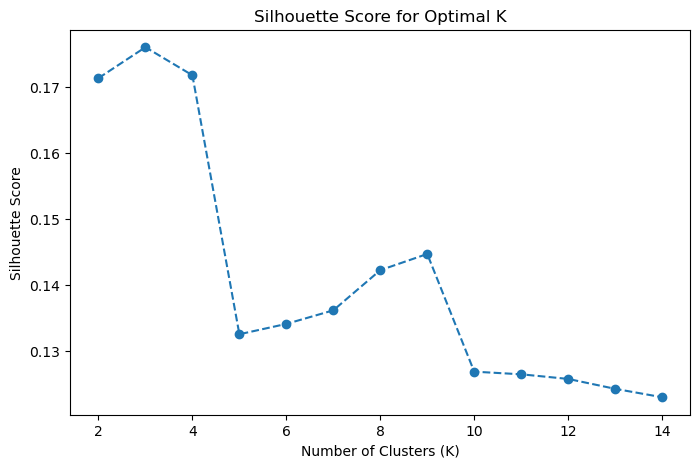

In [11]:
from sklearn.metrics import silhouette_score

# Test different K values
sil_scores = []
K_range = range(2, 15)  # Start from 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(z_score_df.iloc[:, 1:])
    sil_scores.append(silhouette_score(z_score_df.iloc[:, 1:], cluster_labels))

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.show()

In [12]:
from sklearn.cluster import KMeans

num_clusters = 20  # Adjust as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(z_score_df.iloc[:, 1:])  # Use standardized data


C:\Users\hp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [13]:
# Add clustering results to the DataFrame
community_a["prediction"] = ["clust" + str(c) for c in cluster_labels]

# Select the final output format with ordered columns
output = community_a[["xxx", "prediction"]].copy()  # Ensure a clean DataFrame
output.insert(0, "id", range(len(output)))  # Add an "id" column starting from 0

# Save to CSV
output.to_csv("kmeans_coelution.csv", index=False)

# Show the first few rows to verify
print(output.head())

   id        xxx prediction
0   0  0002Y95AH     clust2
1   1  00BDGD39O     clust0
2   2  00BXY8FC6     clust7
3   3  00GQL2IWT    clust19
4   4  00W2KCFX9     clust5
